# LatentMind V6 — Colab Notebook

**Training-first pipeline**: synthesizes agentic traces → trains the policy brain → loads the agent → runs tests.

The brain is a trained 3-head MLP. It picks one action at a time — rag · sql · chart · email · template — and re-decides after each step, stopping when its *continue* score drops below the seuil.

Requires: T4 or L4 GPU runtime.

In [20]:
# ─── GPU CLEANUP — run this any time before re-running the agent cells ───────
# Releases all model weights from VRAM so you can reload without OOM.
# Safe to run even on the very first pass (does nothing if nothing is loaded).

import gc, sys, torch

def cleanup(verbose: bool = True) -> None:
    freed: list[str] = []

    # SLM (3B main model + polisher)
    try:
        import v6.slm as _m
        if _m._slm is not None:
            for tid in list(_m._slm._store.keys()):
                _m._slm.clear_thread(tid)
            del _m._slm.model
            _m._slm = None
            freed.append("SLM 3B")
        if _m._polisher is not None:
            del _m._polisher.model
            _m._polisher = None
            freed.append("polisher (small)")
    except Exception:
        pass

    # BGE-M3 encoder + retriever
    try:
        import v6.knowledge as _m
        if _m._encoder is not None:
            del _m._encoder.model
            _m._encoder = None
            freed.append("BGE-M3")
        _m._retriever = None
    except Exception:
        pass

    # Brain + schema singletons
    try:
        import v6.brain as _m
        if _m._brain is not None:
            _m._brain = None
            freed.append("brain head")
    except Exception:
        pass
    try:
        import v6.schema as _m
        _m._schema = None
    except Exception:
        pass

    # Garbage-collect + CUDA cache
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        alloc  = torch.cuda.memory_allocated() / 1e9
        total  = torch.cuda.get_device_properties(0).total_memory / 1e9
        status = f"{alloc:.2f} GB / {total:.1f} GB in use after cleanup"
    else:
        status = "no CUDA device"

    if verbose:
        if freed:
            print("Released:", ", ".join(freed))
        else:
            print("Nothing was loaded — nothing to release")
        print(status)
        print("Ready to re-run Cell 7.")

cleanup()

Released: SLM 3B, polisher 0.5B, BGE-M3, brain head
0.01 GB / 23.7 GB in use after cleanup
Ready to re-run Cell 7.


In [21]:
# Core inference + RAG
!pip install 'transformers>=4.46.0' 'sentence-transformers>=3.0.0' 'accelerate>=0.27.0'
print("✓ transformers, sentence-transformers, accelerate")

# Graph + math
!pip install 'langgraph>=0.2.0' 'bitsandbytes>=0.43.0' scipy matplotlib
print("✓ langgraph, bitsandbytes, scipy, matplotlib")

# Utils
!pip install jinja2 pydantic pymysql mysql-connector-python
print("✓ jinja2, pydantic, mysql connectors")

print("\n✓ Setup complete! Ready to load agent.")

✓ transformers, sentence-transformers, accelerate
✓ langgraph, bitsandbytes, scipy, matplotlib
✓ jinja2, pydantic, mysql connectors

✓ Setup complete! Ready to load agent.


In [22]:
from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, sys, shutil

REPO_URL = 'https://github.com/Hamza09Hamza/Latent-Djezzy.git'
REPO_DIR = '/content/Latent-Djezzy'
BRANCH   = 'v6-clean'

# Move to a stable dir first — if a previous run did os.chdir(REPO_DIR)
# and then we rmtree it, git can't read the (now-deleted) cwd.
os.chdir('/content')

if os.path.isdir(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print('cleaned up old repo')

subprocess.run(
    ['git', 'clone', '--depth=1', '--branch', BRANCH, REPO_URL, REPO_DIR],
    check=True)
print(f'cloned {BRANCH} → {REPO_DIR}')

for mod in list(sys.modules.keys()):
    if 'v6' in mod:
        del sys.modules[mod]

os.chdir(REPO_DIR)
print('repo ready:', REPO_DIR)

head_path = 'models/brain_head.pt'
if os.path.isfile(head_path):
    size_mb = os.path.getsize(head_path) / 1e6
    print(f'✓ Trained brain head found ({size_mb:.1f} MB) — will skip training')
else:
    print('! Trained brain head NOT found — Cells 6–7 will build it (~2 min on T4)')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cleaned up old repo
cloned v6-clean → /content/Latent-Djezzy
repo ready: /content/Latent-Djezzy
! Trained brain head NOT found — Cells 6–7 will build it (~2 min on T4)


In [23]:
import shutil, os

# Database location — checks LatentDjezzy folder first, falls back to MyDrive root
LOCAL_DB   = "/content/interndb.sqlite"

possible_locations = [
    "/content/drive/MyDrive/LatentDjezzy/interndb.sqlite",
    "/content/drive/MyDrive/interndb.sqlite",
]

DRIVE_DB = None
for loc in possible_locations:
    if os.path.isfile(loc):
        DRIVE_DB = loc
        break

if not DRIVE_DB:
    print("⚠ Database not found in:")
    for loc in possible_locations:
        print(f"    {loc}")
    print("\nPlease ensure interndb.sqlite is in /MyDrive/LatentDjezzy/ or /MyDrive/")
else:
    if not os.path.isfile(LOCAL_DB):
        shutil.copy(DRIVE_DB, LOCAL_DB)
        print(f"✓ copied {os.path.getsize(LOCAL_DB):,} bytes → {LOCAL_DB}")
    else:
        print("✓ SQLite already present:", LOCAL_DB)

# Create output dirs on Drive so charts and emails are persisted
output_base = "/content/drive/MyDrive/LatentDjezzy/v6_output"
for d in [
    f"{output_base}/charts",
    f"{output_base}/emails",
    f"{output_base}/reports",
]:
    os.makedirs(d, exist_ok=True)
print(f"✓ Output dirs ready on Drive → {output_base}/")


✓ SQLite already present: /content/interndb.sqlite
✓ Output dirs ready on Drive → /content/drive/MyDrive/LatentDjezzy/v6_output/


In [ ]:
import os, warnings, logging

# Suppress noisy transformers deprecation warnings
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

os.environ["V6_USE_SQLITE"]    = "1"
os.environ["V6_SQLITE_PATH"]   = "/content/interndb.sqlite"

# ── SQL generator model size — the big toggle ────────────────────────────
# "3b" → Qwen2.5-Coder-3B-Instruct (default, ~6.4 GB fp16, fast)
# "7b" → Qwen2.5-Coder-7B-Instruct (best SQL quality, ~14 GB fp16 → use 4BIT=1)
os.environ["V6_SLM_SIZE"]      = "3b"

os.environ["V6_4BIT"]           = "0"   # set "1" when V6_SLM_SIZE="7b" on T4 16GB
os.environ["V6_SPECULATIVE"]    = "1"   # 0.5B drafter → 2-4x speed
os.environ["V6_CONSTRAINED_SQL"] = "0"  # "1" = grammar-mask SQL output (~40% fewer tokens)

# Polisher (small natural-language refiner)
os.environ["V6_POLISHER_HUB_ID"] = "Qwen/Qwen2.5-1.5B-Instruct"

# Leave SLM_OVERRIDE empty so V6_SLM_SIZE picks the model; set it to force
# a specific Hub id (e.g. "Qwen/Qwen2.5-Coder-3B-Instruct").
os.environ["V6_SLM_OVERRIDE"]   = ""

os.environ["V6_OUTPUT_DIR"]     = "/content/drive/MyDrive/LatentDjezzy/v6_output"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
device = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
size = os.environ.get("V6_SLM_SIZE", "3b")
quant = "4-bit" if os.environ.get("V6_4BIT") == "1" else "fp16"
print(f"GPU:                {device}  ({total_gb:.1f} GB)")
print(f"SQL gen model:      Qwen2.5-Coder-{size.upper()} ({quant})")
print(f"Polisher:           {os.environ['V6_POLISHER_HUB_ID']}")
print(f"Speculative dec.:   {'✓ ON' if os.environ.get('V6_SPECULATIVE') == '1' else '✗ OFF'}")
print(f"Constrained SQL:    {'✓ ON' if os.environ.get('V6_CONSTRAINED_SQL') == '1' else '✗ OFF'}")
print(f"Output dir:         /content/drive/MyDrive/LatentDjezzy/v6_output")

In [25]:
import os

# Set True to re-synthesize traces even if brain_head.pt already exists.
# Always set True after pulling new code that changed brain_data.py.
FORCE_RETRAIN = True

head_path = 'models/brain_head.pt'
if not FORCE_RETRAIN and os.path.isfile(head_path):
    print('Skipping trace synthesis (FORCE_RETRAIN=False and head already exists)')
else:
    # Synthesize agentic traces — the editable policy spec — for the brain.
    # Output: v6/data/brain_train.jsonl
    print('Synthesizing agentic traces...')
    !python3 -m v6.brain_data
    !echo "Rows in brain_train.jsonl:" && wc -l v6/data/brain_train.jsonl


Synthesizing agentic traces...
wrote 8028 training rows → /content/Latent-Djezzy/v6/data/brain_train.jsonl
  by intent       : {'data': 7644, 'meta': 26, 'unanswerable': 71, 'definition': 248, 'greeting': 39}
  by action label : {'chart': 290, 'sql': 1878, 'rag': 1832, 'email': 330, 'template': 380}
  continue 0/1    : 3318 stop / 4710 go
  next: python3 -m v6.train_brain
Rows in brain_train.jsonl:
8028 v6/data/brain_train.jsonl


In [26]:
import os

# Set True to retrain even if brain_head.pt already exists.
FORCE_RETRAIN = True

head_path = 'models/brain_head.pt'
if not FORCE_RETRAIN and os.path.isfile(head_path):
    print('Brain head already trained; skipping (set FORCE_RETRAIN=True to redo)')
else:
    if os.path.isfile(head_path):
        os.remove(head_path)  # remove stale checkpoint before retraining
    # Train the 3-head MLP (intent · action · continue).
    # 200 epochs on the 8k-row dataset ~ 3-4 min on T4.
    # Output: models/brain_head.pt
    print('Training brain head (200 epochs)...')
    !python3 -m v6.train_brain --epochs 200

if os.path.isfile(head_path):
    print('\n✓ Brain ready:', head_path)
else:
    print('\n✗ Training did not produce', head_path, '— check the log above')


Training brain head (200 epochs)...
loaded 8028 rows; encoding with BGE-M3 (one-time)...
Loading weights: 100% 391/391 [00:00<00:00, 1158.09it/s, Materializing param=pooler.dense.weight]                               
  epoch  40 | loss 1.4968 | val intent 0.870 | action 0.983 | continue 0.834
  epoch  80 | loss 0.4813 | val intent 0.977 | action 0.993 | continue 0.914
  epoch 120 | loss 0.2575 | val intent 0.989 | action 0.999 | continue 0.940
  epoch 160 | loss 0.1740 | val intent 0.994 | action 0.999 | continue 0.951
  epoch 200 | loss 0.1329 | val intent 0.997 | action 0.999 | continue 0.962

saved → /content/Latent-Djezzy/models/brain_head.pt
use it:  python3 -m v6.cli

✓ Brain ready: models/brain_head.pt


In [27]:
import sys, os, torch
sys.path.insert(0, "/content/Latent-Djezzy")

# Free any previously loaded models before (re-)loading — prevents OOM on re-run
try:
    cleanup(verbose=False)
except NameError:
    pass  # cleanup not defined yet (first run) — that's fine

from v6.graph import LatentMindV6
from v6.slm import get_slm, get_polisher
from v6.brain import get_brain

print("Loading BGE-M3 encoder + SLM (downloads on first run)…")
agent = LatentMindV6()
get_slm()    # force-load the main model so VRAM is allocated before queries
get_brain()  # force-load the trained brain head (fails fast if not trained)

print("\nLoading polisher (1.5B — natural-language refiner)…")
try:
    get_polisher()
    print("✓ Polisher ready")
except Exception as _e:
    print(f"  Polisher unavailable ({_e}) — raw answers will be shown instead")

if torch.cuda.is_available():
    alloc_gb = torch.cuda.memory_allocated() / 1e9
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nGPU: {alloc_gb:.1f} GB / {total_gb:.1f} GB  "
          f"(headroom ~{total_gb - alloc_gb:.1f} GB)")

Loading BGE-M3 encoder + SLM (downloads on first run)…


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


Loading polisher (0.5B — ~1 GB, streams the final answer)…


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

✓ Polisher ready

GPU: 10.6 GB / 23.7 GB  (headroom ~13.1 GB)


In [ ]:
from v6.config import V6Config

print("\n" + "="*60)
print("Configuration Verification")
print("="*60)
print(f"SLM size:             {V6Config.SLM_SIZE}")
print(f"SLM model:            {V6Config.slm_id()}")
print(f"Polisher:             {V6Config.POLISHER_HUB_ID}")
print(f"4-bit quantization:   {'✓ Enabled' if V6Config.USE_4BIT else '✗ Disabled'}")
print(f"Constrained SQL:      {'✓ ON' if V6Config.USE_CONSTRAINED_SQL else '✗ OFF'}")
print(f"Brain head:           {V6Config.BRAIN_HEAD_PATH}")
print(f"Brain seuil:          {V6Config.BRAIN_SEUIL}  (continue ≥ this → keep going)")
print(f"Brain max steps:      {V6Config.BRAIN_MAX_STEPS}")
print("="*60 + "\n")
print("Ready to run queries. Try: ask('Hello, what can you do?')")

In [29]:
import time, os, sys
from v6.state import initial_state
from IPython.display import display, Image, Markdown

_DIM, _RESET = "\033[2m", "\033[0m"

def _type(text, delay=0.005):
    # typewriter effect for the dim "thinking" lines
    for ch in text:
        sys.stdout.write(ch)
        sys.stdout.flush()
        time.sleep(delay)

def ask(question, thread="main"):
    # One turn: stream the brain's thinking, then the polished answer.
    config = {"configurable": {"thread_id": thread}, "recursion_limit": 60}
    state  = initial_state(question, thread)

    print(f"\n{'='*60}")
    print(f"Q: {question}")
    print(f"{'='*60}")
    t0 = time.time()

    shown = 0
    final_answer  = ""
    chart_path    = ""
    document_path = ""
    email_draft   = None
    intent        = ""
    timings       = {}

    for event in agent.graph.stream(state, config=config, stream_mode="updates"):
        for node, data in event.items():
            if not data:
                continue
            # stream any new thoughts as dim "thinking" lines
            thoughts = data.get("thoughts")
            if thoughts and len(thoughts) > shown:
                for th in thoughts[shown:]:
                    if th.get("kind") == "thinking":
                        sys.stdout.write(_DIM + "  💭 ")
                        _type(th["text"])
                        print(_RESET)
                shown = len(thoughts)
            if data.get("timings"):
                timings = data["timings"]
            # transparent view of the brain's decision each tick
            if node == "brain":
                intent = data.get("intent", intent)
                act    = data.get("next_action", "")
                cont   = data.get("continue_score", 0.0)
                print(f"{_DIM}     → {act}  (continue {cont:.2f}){_RESET}")
            elif node == "chart":
                chart_path = data.get("chart_path", "") or chart_path
            elif node == "template":
                document_path = data.get("document_path", "") or document_path
            elif node == "email":
                email_draft = data.get("email_draft") or email_draft
            elif node == "communicator":
                final_answer = data.get("final_answer", "")

    elapsed = time.time() - t0

    # ── stream the polished answer as the normal message ──────────────────
    print(f"\nAnswer ({elapsed:.1f}s):")
    _FAILURE = ("couldn't build", "failed to run", "no matching rows",
                "wasn't able to pull", "not sure which kpi")
    is_failure = any(p in (final_answer or "").lower() for p in _FAILURE)
    should_polish = (intent == "data" and final_answer
                     and len(final_answer) > 40 and not is_failure
                     and not chart_path and not email_draft
                     and not document_path)
    if should_polish:
        try:
            from v6.slm import get_polisher
            for token in get_polisher().stream(final_answer, question):
                print(token, end="", flush=True)
            print()
        except Exception:
            print(final_answer)
    else:
        print(final_answer or "(no answer)")

    # ── display chart inline ──────────────────────────────────────────────
    if chart_path and os.path.isfile(chart_path):
        print()
        display(Image(chart_path))
    elif chart_path:
        print(f"  (chart path reported but file missing: {chart_path})")

    # ── report ────────────────────────────────────────────────────────────
    if document_path:
        print(f"  Report saved → {document_path}")

    # ── email draft + save to Drive ───────────────────────────────────────
    if email_draft:
        print()
        to = email_draft.get("to") or "(no recipient matched)"
        display(Markdown(f"**Email draft**\n\n"
                         f"**To:** {email_draft.get('to_name', '?')} <{to}>  \n"
                         f"**Subject:** {email_draft.get('subject', '')}\n\n"
                         f"---\n\n{email_draft.get('body', '')}"))
        try:
            import datetime
            from v6.config import V6Config
            email_dir = os.path.join(V6Config.output_dir(), "emails")
            os.makedirs(email_dir, exist_ok=True)
            stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            email_path = os.path.join(email_dir, f"email_{stamp}.txt")
            with open(email_path, "w") as f:
                f.write(f"To: {email_draft.get('to_name', '?')} <{to}>\n")
                f.write(f"Subject: {email_draft.get('subject', '')}\n\n")
                f.write(email_draft.get("body", ""))
            print(f"  Email saved → {email_path}")
        except Exception as e:
            print(f"  (could not save email: {e})")

    # ── performance breakdown — where the T4 time actually went ───────────
    import torch
    brain_ms = sum(v for k, v in timings.items() if k.startswith("brain"))
    sql_ms   = sum(v for k, v in timings.items() if k.startswith("sql"))
    rag_ms   = timings.get("rag_ms", 0.0)
    n_ticks  = sum(1 for k in timings if k.startswith("brain"))
    line = (f"⏱  {n_ticks} brain ticks {brain_ms:.0f}ms · "
            f"rag {rag_ms / 1000:.2f}s · sql {sql_ms / 1000:.2f}s · "
            f"total {elapsed:.1f}s")
    if torch.cuda.is_available():
        line += f" · VRAM {torch.cuda.memory_allocated() / 1e9:.1f} GB"
    print(f"{_DIM}{line}{_RESET}")

    # ── free the KV cache to keep VRAM flat across queries ────────────────
    try:
        from v6.slm import get_slm
        get_slm().clear_thread(thread)
    except Exception:
        pass
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print()

In [30]:
# Greeting in French
ask("Salam, qu'est-ce que tu peux faire ?")


Q: Salam, qu'est-ce que tu peux faire ?
  💭 Let me answer that directly.
     → rag  (continue 0.22)

Answer (0.2s):
I'm LatentMind V6, an analytics agent over the interndb telecom database. I turn a question into SQL, run it, and report the numbers — and on request I chart the result, draft an email, or fill a report. I remember the conversation, so follow-ups like 'and for Oran?' work.
⏱  1 brain ticks 19ms · rag 0.00s · sql 0.00s · total 0.2s · VRAM 10.6 GB



In [31]:
# Definition — no sql
ask("What does EBITDA margin mean?")


Q: What does EBITDA margin mean?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.93)

Answer (1.5s):
KPI 'ebitda_margin' in table fpa_profitability (segment all, unit %). EBITDA margin as percentage of total revenue. Also called: EBITDA margin, marge EBITDA, operating margin, EBITDA percent. Use when asked about: profitability, operating margins, performance report, financial efficiency, quarterly margins.
⏱  1 brain ticks 35ms · rag 0.00s · sql 0.00s · total 1.5s · VRAM 10.6 GB



In [32]:
# fpa_profitability, Batna, relative time
ask("Show me the gross margin for Batna last quarter")


Q: Show me the gross margin for Batna last quarter
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.56).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['fpa_profitability', 'dim_location'].
  💭 Resolved wilayas: Batna=61 communes.
  💭 Built the query: SELECT SUM(f.gross_margin) AS gross_margin
FROM fpa_profitability f
JOIN dim_location dl ON f.location_id = dl.location_id
WHERE f.location_id IN (SELECT location_id FROM dim_location WHERE wilaya = 'Batna') LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.04)

Answer (10.1s):
gross_margin: 104,266.85
⏱  3 brain ticks 38ms · rag 0.02s · sql 7.11s · total 10.1s · VRAM 10.7 GB




Q: Which wilaya had the highest prepaid recharge rate in 2025?
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.54).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['prepaid_kpi', 'dim_location'].
  💭 Retrying SQL — last attempt: query filters by wilaya/location_id but the user named no specific wilaya; remove the filter and use GROUP BY dl.wilaya .
  💭 Built the query: SELECT dl.wilaya, AVG(p.recharge_rate) AS recharge_rate
FROM prepaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
GROUP BY dl.wilaya LIMIT 1000
  💭 Ran it — 58 row(s) back.
  💭 The data's in — let me turn it into a chart.
     → chart  (continue 0.56)
  💭 Chart saved.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.04)

Answer (15.7s):
58 rows returned:
  wilaya: Adrar | recharge_rate: 38.5145
  wilaya: Alger | recharge_rate: 39.1108
  wilaya: Annaba | rech

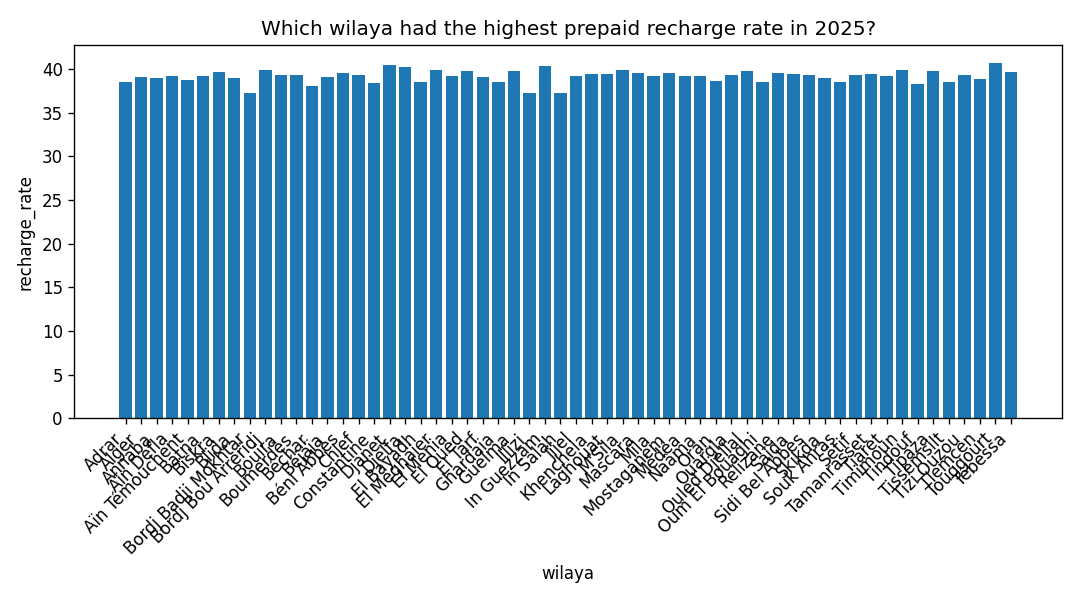

⏱  4 brain ticks 41ms · rag 0.02s · sql 11.76s · total 15.7s · VRAM 10.7 GB



In [33]:
# prepaid_kpi, ranking
ask("Which wilaya had the highest prepaid recharge rate in 2025?")


Q: Plot the net income trend for Tlemcen and Setif over 2025
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.42).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['fpa_profitability', 'dim_location'].
  💭 Resolved wilayas: Tlemcen=53 communes, Sétif=60 communes.
  💭 Built the query: SELECT dl.wilaya, SUM(f.net_income) AS net_income
FROM fpa_profitability f
JOIN dim_location dl ON f.location_id = dl.location_id
WHERE f.location_id IN (SELECT location_id FROM dim_location WHERE wilaya IN ('Tlemcen', 'Sétif'))
GROUP BY dl.wilaya LIMIT 1000
  💭 Ran it — 2 row(s) back.
  💭 The data's in — let me turn it into a chart.
     → chart  (continue 0.93)
  💭 Chart saved.
  💭 I have what I need — writing the answer now.
     → chart  (continue 0.28)

Answer (12.9s):
2 rows returned:
  wilaya: Sétif | net_income: 491,926,011.79
  wilaya: Tlemcen | net_income: 432,742,268.07

📊 Ch

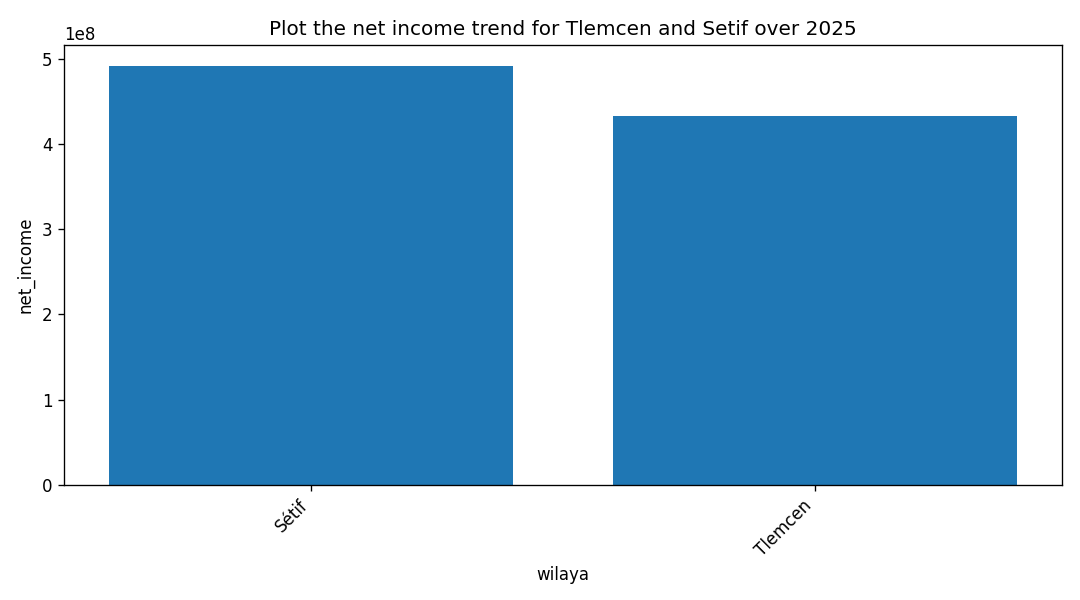

⏱  4 brain ticks 41ms · rag 0.02s · sql 9.16s · total 12.9s · VRAM 10.7 GB



In [34]:
# Chart trend, two wilayas
ask("Plot the net income trend for Tlemcen and Setif over 2025")

In [35]:
# opex_capex table
ask("What's the capex breakdown for IT and network this year?")


Q: What's the capex breakdown for IT and network this year?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.99)
  💭 Pulled reference knowledge (grounding 0.59).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['opex_capex'].
  💭 Retrying SQL — last attempt: query filters by wilaya/location_id but the user named no specific wilaya; remove the filter and use GROUP BY dl.wilaya .
  💭 Built the query: SELECT dl.wilaya, SUM(o.capex_network) AS capex_network, SUM(o.capex_it) AS capex_it
FROM opex_capex o
JOIN dim_location dl ON o.location_id = dl.location_id
GROUP BY dl.wilaya LIMIT 1000
  💭 Ran it — 58 row(s) back.
  💭 I have what I need — writing the answer now.
     → chart  (continue 0.40)

Answer (15.5s):
The total capital expenditure (capex) for IT and network across all wilayas this year is $28,841,305.97 million.
⏱  3 brain ticks 39ms · rag 0.02s · sql 12.21s · total 15.5s · VRAM 10.7 GB



In [36]:
# migration_rate, postpaid_kpi
ask("How many postpaid subscribers migrated in Bejaia last month?")


Q: How many postpaid subscribers migrated in Bejaia last month?
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.60).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['postpaid_kpi', 'dim_location'].
  💭 Resolved wilayas: Béjaïa=52 communes.
  💭 Built the query: SELECT AVG(p.migration_rate) AS migration_rate
FROM postpaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
WHERE p.location_id IN (SELECT location_id FROM dim_location WHERE wilaya = 'Béjaïa') LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.06)

Answer (9.8s):
migration_rate: 1.2646
⏱  3 brain ticks 42ms · rag 0.02s · sql 6.89s · total 9.8s · VRAM 10.7 GB



In [37]:
# Follow-up — wilaya only
ask("and for Tiaret?")


Q: and for Tiaret?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.97)
  💭 Pulled reference knowledge (grounding 0.00).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['postpaid_kpi', 'dim_location'].
  💭 I have what I need — writing the answer now.
     → email  (continue 0.01)

Answer (5.6s):
I'm not sure which KPI you mean. Could you name one — revenue, ARPU, churn, subscribers, EBITDA, OPEX/CAPEX — and optionally a wilaya and period?
⏱  3 brain ticks 43ms · rag 0.02s · sql 4.26s · total 5.6s · VRAM 10.7 GB



In [38]:
# Follow-up — template only
ask("Put it in a report")


Q: Put it in a report
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.54).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Let me put this into a report.
     → template  (continue 0.51)
  💭 Report saved.
  💭 I have what I need — writing the answer now.
     → template  (continue 0.03)

Answer (4.8s):
I wasn't able to pull the data for that. Could you rephrase it with a clearer KPI, wilaya and period?

📄 Report saved: /content/drive/MyDrive/LatentDjezzy/v6_output/reports/report_20260525_141359.md
  Report saved → /content/drive/MyDrive/LatentDjezzy/v6_output/reports/report_20260525_141359.md
⏱  4 brain ticks 48ms · rag 0.02s · sql 3.49s · total 4.8s · VRAM 10.7 GB



In [39]:
# global_revenue + email
ask("Email the B2B revenue breakdown to the finance director")


Q: Email the B2B revenue breakdown to the finance director
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.68).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['global_revenue', 'dim_location'].
  💭 Resolved wilayas: Annaba=12 communes, Aïn Defla=36 communes.
  💭 Built the query: SELECT dl.wilaya, SUM(g.revenue_b2b) AS revenue_b2b
FROM global_revenue g
JOIN dim_location dl ON g.location_id = dl.location_id
WHERE g.location_id IN (
    SELECT location_id FROM dim_location WHERE wilaya IN ('Annaba', 'Aïn Defla')
)
GROUP BY dl.wilaya LIMIT 1000
  💭 Ran it — 2 row(s) back.
  💭 Let me draft an email with these results.
     → email  (continue 1.00)
  💭 Drafted an email to boukader hamza.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.18)

Answer (12.7s):
2 rows returned:
  wilaya: Annaba | revenue_b2b: 117,384,134.46
  wilaya: Aïn Defla | re

**Email draft**

**To:** boukader hamza <boukaderhamza71@gmail.com>  
**Subject:** Telecom analytics: Email the B2B revenue breakdown to the finance director

---

Hi boukader hamza,

Here are the analytics figures you asked for.

2 rows returned:
  wilaya: Annaba | revenue_b2b: 117,384,134.46
  wilaya: Aïn Defla | revenue_b2b: 341,017,699.42

| wilaya | revenue_b2b |
| --- | --- |
| Annaba | 117,384,134.46 |
| Aïn Defla | 341,017,699.42 |

Best regards,
LatentMind V6 — automated analytics assistant

---
This message was drafted automatically from the query:
  "Email the B2B revenue breakdown to the finance director"
Review the figures before sending.

  Email saved → /content/drive/MyDrive/LatentDjezzy/v6_output/emails/email_20260525_141412.txt
⏱  4 brain ticks 45ms · rag 0.02s · sql 8.98s · total 12.7s · VRAM 10.7 GB



In [40]:
# Unanswerable fake KPI
ask("What is the brand sentiment score for Oran?")


Q: What is the brand sentiment score for Oran?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.96)

Answer (0.3s):
I can't answer that — it needs a KPI or table that isn't in the database. Try revenue, ARPU, churn, subscribers, EBITDA, or OPEX/CAPEX for an Algerian wilaya.
⏱  1 brain ticks 44ms · rag 0.00s · sql 0.00s · total 0.3s · VRAM 10.6 GB




Q: Chart the OPEX breakdown by category for Q3 2025 and email it
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.58).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['opex_capex'].
  💭 Retrying SQL — last attempt: query filters by wilaya/location_id but the user named no specific wilaya; remove the filter and use GROUP BY dl.wilaya .
  💭 Built the query: SELECT dl.wilaya, SUM(o.opex_network) AS opex_network, SUM(o.opex_marketing) AS opex_marketing
FROM opex_capex o
JOIN dim_location dl ON o.location_id = dl.location_id
GROUP BY dl.wilaya LIMIT 1000
  💭 Ran it — 58 row(s) back.
  💭 The data's in — let me turn it into a chart.
     → chart  (continue 1.00)
  💭 Chart saved.
  💭 Let me draft an email with these results.
     → email  (continue 0.92)
  💭 Drafted an email, but no recipient was named.
  💭 I have what I need — writing the answer now.
     → email  (contin

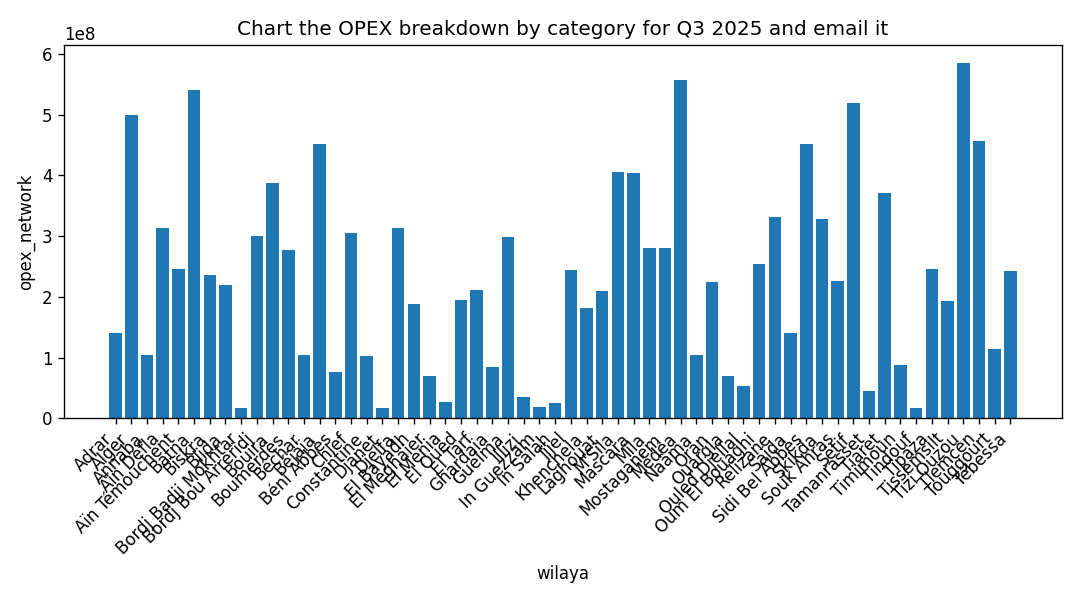

**Email draft**

**To:** None <(no recipient matched)>  
**Subject:** Telecom analytics: Chart the OPEX breakdown by category for Q3 2025 and email i

---

Hi there,

Here are the analytics figures you asked for.

58 rows returned:
  wilaya: Adrar | opex_network: 139,691,693.53 | opex_marketing: 55,173,362.49
  wilaya: Alger | opex_network: 498,697,701.89 | opex_marketing: 190,042,765.22
  wilaya: Annaba | opex_network: 104,875,705.92 | opex_marketing: 39,067,874.48
  wilaya: Aïn Defla | opex_network: 312,752,444.61 | opex_marketing: 122,406,845.23
  wilaya: Aïn Témouchent | opex_network: 245,731,068.07 | opex_marketing: 93,090,519.96
  wilaya: Batna | opex_network: 539,940,186.18 | opex_marketing: 205,876,162.88
  wilaya: Biskra | opex_network: 236,275,326.64 | opex_marketing: 92,585,140.98
  wilaya: Blida | opex_network: 219,785,086.04 | opex_marketing: 85,963,828.14
  ... (50 more rows)

| wilaya | opex_network | opex_marketing |
| --- | --- | --- |
| Adrar | 139,691,693.53 | 55,173,362.49 |
| Alger | 498,697,701.89 | 190,042,765.22 |
| Annaba | 104,875,705.92 | 39,067,874.48 |
| Aïn Defla | 312,752,444.61 | 122,406,845.23 |
| Aïn Témouchent | 245,731,068.07 | 93,090,519.96 |
| Batna | 539,940,186.18 | 205,876,162.88 |
| Biskra | 236,275,326.64 | 92,585,140.98 |
| Blida | 219,785,086.04 | 85,963,828.14 |
| Bordj Badji Mokhtar | 17,542,155.29 | 7,296,159.67 |
| Bordj Bou Arreridj | 299,520,098.72 | 112,999,790.33 |
| Bouira | 387,532,426.74 | 152,827,694.91 |
| Boumerdès | 277,394,216.07 | 109,111,977.09 |
| Béchar | 104,571,462.45 | 40,737,889.10 |
| Béjaïa | 451,586,750.04 | 173,196,495.93 |
| Béni Abbès | 75,519,762.06 | 30,610,383.38 |

_(43 more rows not shown)_

Best regards,
LatentMind V6 — automated analytics assistant

---
This message was drafted automatically from the query:
  "Chart the OPEX breakdown by category for Q3 2025 and email it"
Review the figures before sending.

  Email saved → /content/drive/MyDrive/LatentDjezzy/v6_output/emails/email_20260525_141431.txt
⏱  5 brain ticks 48ms · rag 0.02s · sql 13.09s · total 17.6s · VRAM 10.7 GB



In [41]:
# Multi-capability, opex_capex
ask("Chart the OPEX breakdown by category for Q3 2025 and email it")

In [42]:
# Times agent.graph.invoke directly (no UI polish / typewriter) so the numbers
# are the real engine cost. The brain MLP is milliseconds — the SLM dominates.
import time, torch
from v6.state import initial_state
from v6.slm import get_slm

BENCH = [
    "Salam, qu'est-ce que tu peux faire ?",
    "What does EBITDA margin mean?",
    "Show me the gross margin for Batna last quarter",
    "Which wilaya had the highest prepaid recharge rate in 2025?",
    "Plot the net income trend for Tlemcen and Setif over 2025",
    "Email the B2B revenue breakdown to the finance director",
]

hdr = f"{'query':<46}{'intent':<11}{'steps':>6}{'brain':>9}{'sql':>9}{'total':>9}"
print(hdr)
print("-" * len(hdr))
tot = 0.0
for q in BENCH:
    t0 = time.time()
    r = agent.graph.invoke(
        initial_state(q, "bench"),
        {"configurable": {"thread_id": "bench"}, "recursion_limit": 60})
    dt = time.time() - t0
    tot += dt
    tm = r.get("timings", {})
    brain_ms = sum(v for k, v in tm.items() if k.startswith("brain"))
    sql_ms   = sum(v for k, v in tm.items() if k.startswith("sql"))
    print(f"{q[:46]:<46}{r.get('intent',''):<11}"
          f"{r.get('brain_step',0):>6}{brain_ms:>7.0f}ms"
          f"{sql_ms/1000:>8.2f}s{dt:>8.2f}s")
    get_slm().clear_thread("bench")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("-" * len(hdr))
print(f"{'AVERAGE per query':<46}{'':<11}{'':>6}{'':>9}{'':>9}"
      f"{tot/len(BENCH):>8.2f}s")
if torch.cuda.is_available():
    a = torch.cuda.memory_allocated() / 1e9
    t = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nVRAM: {a:.2f} GB used / {t:.1f} GB total  ({t-a:.1f} GB free)")
    print("Brain overhead is the 'brain' column — a few ms per query; the "
          "SLM router+sqlgen is the cost centre.")

query                                         intent      steps    brain      sql    total
------------------------------------------------------------------------------------------
Salam, qu'est-ce que tu peux faire ?          meta            1     19ms    0.00s    0.02s
What does EBITDA margin mean?                 definition      1     34ms    0.00s    0.06s
Show me the gross margin for Batna last quartedata            3     42ms    7.33s    7.40s
Which wilaya had the highest prepaid recharge data            4     40ms   11.77s   12.24s
Plot the net income trend for Tlemcen and Setidata            4     38ms    9.20s    9.39s
Email the B2B revenue breakdown to the financedata            4     38ms   10.39s   10.46s
------------------------------------------------------------------------------------------
AVERAGE per query                                                                    6.59s

VRAM: 10.57 GB used / 23.7 GB total  (13.1 GB free)
Brain overhead is the 'brain' column 

In [43]:
import torch
if torch.cuda.is_available():
    alloc  = torch.cuda.memory_allocated()  / 1e9
    reserv = torch.cuda.memory_reserved()   / 1e92
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU  allocated: {alloc:.2f} GB")
    print(f"GPU  reserved:  {reserv:.2f} GB")
    print(f"GPU  total:     {total:.2f} GB")

GPU  allocated: 10.57 GB
GPU  reserved:  0.00 GB
GPU  total:     23.66 GB


In [44]:
# Direct streaming — bypasses the graph, useful for quick SLM checks.
from v6.slm import get_slm

slm = get_slm()
messages = [
    {"role": "system", "content": "You are a helpful telecom analyst."},
    {"role": "user",   "content": "List the top 3 KPIs for a telecom operator."},
]
print("Streaming response:")
for token in slm.stream_generate(messages, max_new_tokens=256):
    print(token, end="", flush=True)
print()

Streaming response:
1. Customer Satisfaction: This is one of the most important KPIs for any telecom operator as it directly impacts their brand reputation and customer loyalty. It can be measured through surveys, feedback forms, and customer complaints.

2. Revenue Growth: This KPI measures the increase in revenue generated by the telecom operator over a specific period. It is an essential metric for assessing the financial performance of the company and identifying areas for growth.

3. Network Performance: This KPI measures the quality of the network, including call quality, data speed, and reliability. It is crucial for ensuring that customers have a good experience while using the telecom services.
